In [13]:
import numpy as np
import torch
from pathlib import Path
from objects.Functions import SpikeFunc
from objects.networks import Network, EvoNet
from utilities.data_sampler import get_train_val_test
from utilities.trainer import base_model_train, evolving_trainer
import matplotlib.pyplot as plt

Path("models").mkdir(parents=True, exist_ok=True)
Path("results").mkdir(parents=True, exist_ok=True)
models_folder = Path("models")
results_folder = Path("results")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


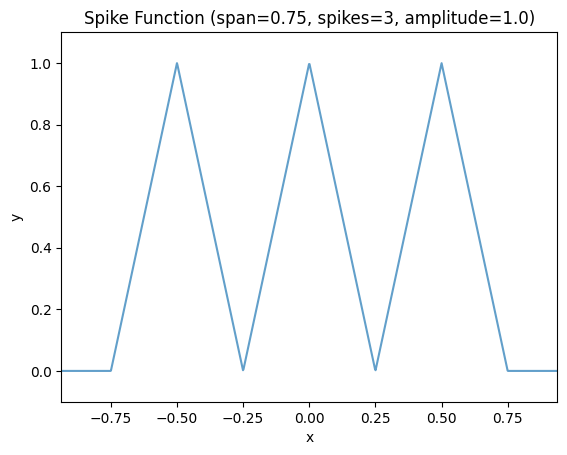

In [14]:
spike = SpikeFunc()
spike.plot()

In [15]:
train, val = get_train_val_test(spike, 42, 10000)

# unpack the tuples
x_train, y_train = train
x_val, y_val = val

train size:	8500
val size:	1500


In [16]:
for hidden_size in [7, 50, 100]:
    break
    Net = Network(hidden_size)
    base_model_train(Net, x_train, y_train, x_val, y_val, epochs=3000, lr=1e-3, device=device, patience=15, plot=True)
    Net.save(filename=f"base_{hidden_size}.pt")

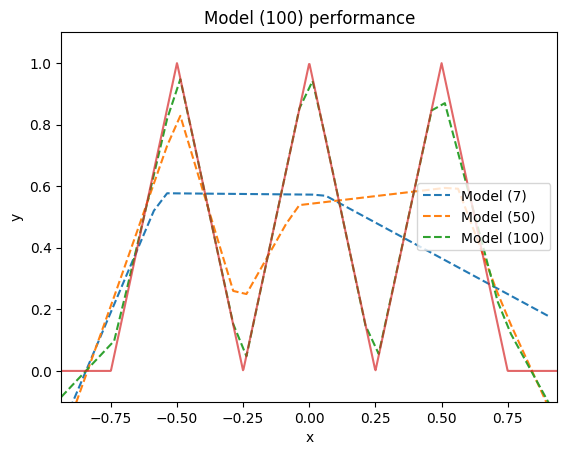

In [17]:
# Let's plot how well the models understands our function.
data = []
for hidden_size in [7, 50, 100]:
    Net = Network(hidden_size)
    Net.load(filename=f"base_{hidden_size}.pt")


    X = np.arange(-spike.span * 1.25, spike.span * 1.25, 0.05) 
    X = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(device)
    Net = Net.to(device)
    Net.eval()
    Y = Net(X).to(device)
    X = X.detach().cpu().squeeze(1).numpy()
    Y = Y.detach().cpu().squeeze(1).numpy()

    data.append((X, Y, f"Model ({hidden_size})"))
    

spike.plot(output_data=data, plot_title=f"Model ({Net.hidden_size}) performance", save_path=results_folder/f"base_model_perf.png")



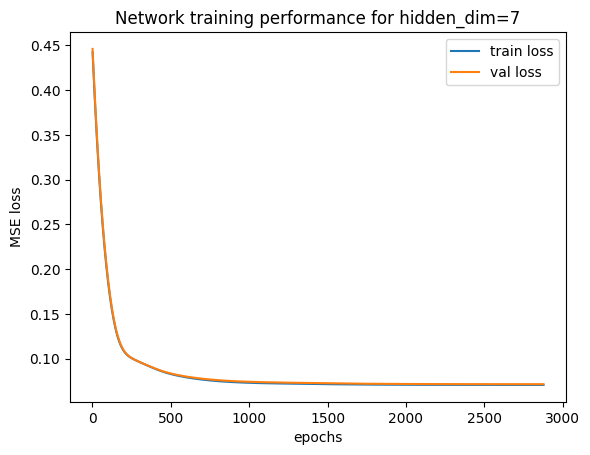

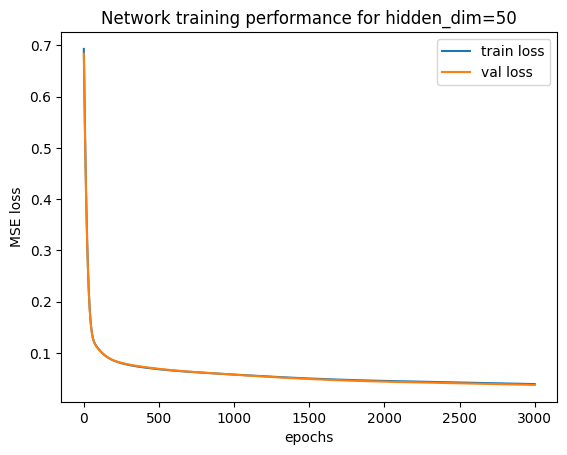

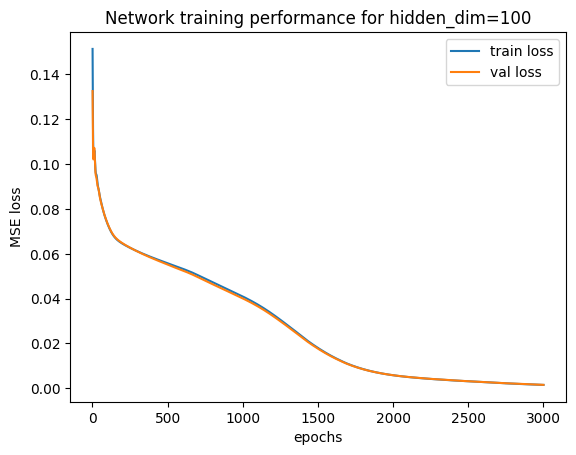

In [18]:
for hidden_size in [7, 50, 100]:
    Net = Network(hidden_size)
    Net.load(filename=f"base_{hidden_size}.pt")
    Net.plot_performance()

## 2. Train evonets on the same data

In [ ]:
# distances = torch.cdist(neuron_data, neuron_data, p=2)

P = [[EvoNet(hidden_size=100)for _ in range(50)]]
populations, best_networks = evolving_trainer(P, x_train, y_train, x_val, y_val, crossover = 0.15, mutation_rate=0.2, K =5, gens = 100, epochs=150, device=device)

Generation:  75


In [ ]:
# Disclaimer this is fully AI generated but it's all correct so yay.
# Prepare data for plotting
generations = len(populations)
fitness_mean = []
fitness_std = []
val_loss_mean = []
val_loss_std = []
hidden_sizes_mean = []
hidden_sizes_std = []

for gen in populations:
    fitness = [net.fitness for net in gen]
    val_loss = [net.val_loss[-1] for net in gen]
    hidden_size = [net.hidden_size for net in gen]

    fitness_mean.append(np.mean(fitness))
    fitness_std.append(np.std(fitness))
    val_loss_mean.append(np.mean(val_loss))
    val_loss_std.append(np.std(val_loss))
    hidden_sizes_mean.append(np.mean(hidden_size))  
    hidden_sizes_std.append(np.std(hidden_size))  

# Create a 1x3 subplot
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Fitness (Mean ± Std)
ax1.errorbar(
    range(generations),
    fitness_mean,
    yerr=fitness_std,
    label="Fitness (Mean ± Std)",
    color="blue",
    capsize=5,
)
ax1.set_xlabel("Generation")
ax1.set_ylabel("Fitness")
ax1.set_title("Fitness Over Generations")
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss (Mean ± Std)
ax2.errorbar(
    range(generations),
    val_loss_mean,
    yerr=val_loss_std,
    label="Val Loss (Mean ± Std)",
    color="orange",
    capsize=5,
)
ax2.set_xlabel("Generation")
ax2.set_ylabel("Validation Loss")
ax2.set_title("Validation Loss Over Generations")
ax2.legend()
ax2.grid(True)

# Plot 3: Hidden Size
# ax3.plot(range(generations), hidden_sizes, marker="o", color="green")
ax3.errorbar(
    range(generations),
    hidden_sizes_mean,
    yerr=hidden_sizes_std,
    label="Val Loss (Mean ± Std)",
    color="green",
    capsize=5,
)
ax3.set_xlabel("Generation")
ax3.set_ylabel("Hidden Size")
ax3.set_title("Hidden Size Over Generations")
ax3.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
best_fitness = float('inf')
best_net = None
for net in populations[-1]:
    if net.fitness < best_fitness:
        best_net = net

In [ ]:
data = []
X = np.arange(-spike.span * 1.25, spike.span * 1.25, 0.05) 
X = torch.tensor(X, dtype=torch.float32).unsqueeze(1).to(device)
net = best_net.to(device)
net.eval()
Y = net(X).to(device)
X = X.detach().cpu().squeeze(1).numpy()
Y = Y.detach().cpu().squeeze(1).numpy()

data.append((X, Y, f"Model ({net.hidden_size})"))
spike.plot(output_data=data, plot_title=f"Best EvoNet ({net.hidden_size}) performance", save_path=results_folder/f"evonet.png")